In [7]:
import kagglehub
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Data Download

In [8]:
path = kagglehub.dataset_download("sujaykapadnis/smoking")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/smoking


## Data Load

In [9]:
train_path = path+'/Training/Training'
validation_path = path+'/Validation/Validation'
test_path = path+'/Testing/Testing'

train_fnames = os.listdir(train_path)
validation_fnames = os.listdir(validation_path)
test_fnames = os.listdir(test_path)

In [10]:
train_fnames

['smoking_0175.jpg',
 'smoking_0480.jpg',
 'notsmoking_0267.jpg',
 'notsmoking_0037.jpg',
 'notsmoking_0379.jpg',
 'notsmoking_0243.jpg',
 'notsmoking_0341.jpg',
 'notsmoking_0245.jpg',
 'notsmoking_0474.jpg',
 'smoking_0248.jpg',
 'smoking_0178.jpg',
 'notsmoking_0001.jpg',
 'smoking_0341.jpg',
 'smoking_0350.jpg',
 'notsmoking_0135.jpg',
 'smoking_0468.jpg',
 'notsmoking_0376.jpg',
 'notsmoking_0139.jpg',
 'smoking_0194.jpg',
 'smoking_0297.jpg',
 'smoking_0221.jpg',
 'notsmoking_0200.jpg',
 'notsmoking_0362.jpg',
 'smoking_0499.jpg',
 'smoking_0376.jpg',
 'smoking_0408.jpg',
 'notsmoking_0210.jpg',
 'notsmoking_0346.jpg',
 'notsmoking_0454.jpg',
 'smoking_0302.jpg',
 'smoking_0052.jpg',
 'smoking_0363.jpg',
 'notsmoking_0464.jpg',
 'notsmoking_0204.jpg',
 'smoking_0267.jpg',
 'smoking_0003.jpg',
 'notsmoking_0552.jpg',
 'smoking_0013.jpg',
 'smoking_0517.jpg',
 'notsmoking_0234.jpg',
 'notsmoking_0009.jpg',
 'notsmoking_0322.jpg',
 'notsmoking_0314.jpg',
 'smoking_0165.jpg',
 'smoki

### Training Dataset

In [11]:
tr_filepaths = []
tr_labels = []
for filename in train_fnames:
    if filename.endswith('.jpg'):
        tr_filepaths.append(os.path.join(train_path, filename))
        if 'notsmoking' in filename:
            tr_labels.append('NotSmoking')
        else:
            tr_labels.append('Smoking')

tr_df = pd.DataFrame({
    'filename': tr_filepaths,
    'class': tr_labels
})

tr_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


train_generator =tr_datagen.flow_from_dataframe(
    dataframe=tr_df,
    x_col='filename',
    y_col='class',
    target_size=(150, 150),
    batch_size=16,
    class_mode='binary'
)

Found 716 validated image filenames belonging to 2 classes.


### Validation Dataset

In [12]:
val_filepaths = []
val_labels = []
for filename in validation_fnames:
    if filename.endswith('.jpg'):
        val_filepaths.append(os.path.join(validation_path, filename))
        if 'notsmoking' in filename:
            val_labels.append('NotSmoking')
        else:
            val_labels.append('Smoking')

val_df = pd.DataFrame({
    'filename': val_filepaths,
    'class': val_labels
})

val_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='class',
    target_size=(150, 150),
    batch_size=16,
    class_mode='binary'
)

Found 180 validated image filenames belonging to 2 classes.


### Test Dataset

In [13]:
ts_filepaths = []
ts_labels = []
for filename in test_fnames:
    if filename.endswith('.jpg'):
        ts_filepaths.append(os.path.join(test_path, filename))
        if 'notsmoking' in filename:
            ts_labels.append('NotSmoking')
        else:
            ts_labels.append('Smoking')

ts_df = pd.DataFrame({
    'filename': ts_filepaths,
    'class': ts_labels
})

ts_datagen = ImageDataGenerator(rescale=1./255)

test_generator = ts_datagen.flow_from_dataframe(
    dataframe=ts_df,
    x_col='filename',
    y_col='class',
    target_size=(150, 150),
    batch_size=16,
    class_mode='binary'
)

Found 224 validated image filenames belonging to 2 classes.


In [14]:
print(train_generator.class_indices)
print(validation_generator.class_indices)
print(test_generator.class_indices)

{'NotSmoking': 0, 'Smoking': 1}
{'NotSmoking': 0, 'Smoking': 1}
{'NotSmoking': 0, 'Smoking': 1}


## Model Develop

간단한 CNN 모델을 사용하여 prediction 진행

In [15]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(150, 150, 3), kernel_initializer='he_normal'),
  layers.BatchNormalization(),
  tf.keras.layers.MaxPooling2D(2,2),

  tf.keras.layers.Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal'),
  layers.BatchNormalization(),
  tf.keras.layers.MaxPooling2D(2,2),

  tf.keras.layers.Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal'),
  layers.BatchNormalization(),
  tf.keras.layers.MaxPooling2D(2,2),

  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(512, activation='relu', kernel_initializer='he_normal'),
  layers.Dropout(0.5),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,495,009 (36.22 MB)

 Trainable params: 9,494,785 (36.22 MB)

 Non-trainable params: 224 (896.00 B)

In [16]:
callback = [tf.keras.callbacks.EarlyStopping(
    monitor='loss', min_delta=0.001, patience=10, verbose=1, restore_best_weights=True)]

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [17]:
history = model.fit(train_generator, validation_data = validation_generator,
                    epochs=100,
                    callbacks=callback
                    )

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 337ms/step - accuracy: 0.6443 - loss: 1.3550 - val_accuracy: 0.5611 - val_loss: 0.9163
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - accuracy: 0.6974 - loss: 0.9040 - val_accuracy: 0.7167 - val_loss: 0.5815
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.6690 - loss: 0.9102 - val_accuracy: 0.7167 - val_loss: 0.5782
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 136ms/step - accuracy: 0.6913 - loss: 0.7300 - val_accuracy: 0.7444 - val_loss: 0.5982
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.6754 - loss: 0.6645 - val_accuracy: 0.7333 - val_loss: 0.6084
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.7249 - loss: 0.5993 - val_accuracy: 0.7389 - val_loss: 0.5453
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - accuracy: 0.6996 - loss: 0.5518 - val_accuracy: 0.7500 - val_loss: 0.5356
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - accuracy: 0.7226 - loss: 0.5686 - val_acc

## Performance check

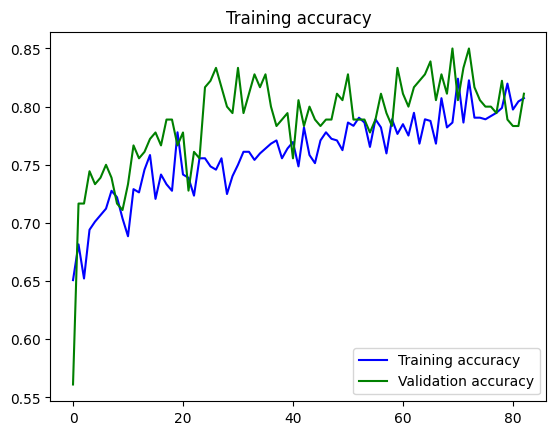

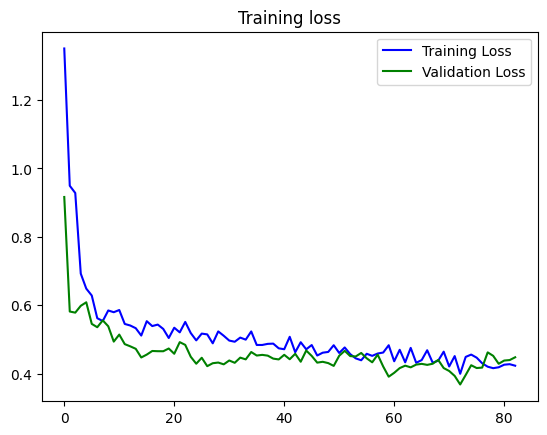

In [18]:
acc = history.history['accuracy']
acc_val = history.history['val_accuracy']
loss = history.history['loss']
loss_val = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, acc_val, 'g', label = 'Validation accuracy')
plt.title('Training accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, loss_val, 'g', label = 'Validation Loss')
plt.title('Training loss')
plt.legend()

plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Confusion Matrix:


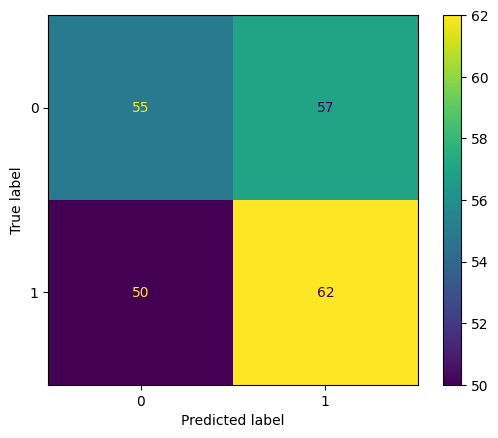

Accuracy: 0.5223
Precision: 0.5210
Recall: 0.5536
F1 Score: 0.5368


In [22]:
preds = model.predict(test_generator, verbose=1)

y_pred = (preds > 0.5).astype(int).reshape(-1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Confusion Matrix:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")